In [3]:
import sys
sys.path.append("..")
import numpy as np
from src.piecewise_landscape import make_log_price_bins, simulate_censored_auctions, sample_piecewise_market, sample_bids_from_value_model, PiecewiseSurvivalLandscape
import src.plots as plots
from src.km_landscape import SegmentKaplanMeierLandscape

%load_ext autoreload
%autoreload 2

ModuleNotFoundError: No module named 'src.piecewise_landscape'

In [4]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from src.data_sim import simulate_uplift_data
from src.dragonnet import TrainConfig, fit_dragonnet, predict_dragonnet
from src.evaluate import (
    summarize_uplift_eval,
    print_eval_summary,
    cumulative_uplift_curve,
    qini_curve_from_probs,
    calibration_by_uplift_bin,
)

# 1. simulate data
df = simulate_uplift_data(n=100_000, seed=42)

feature_cols = [
    "intent",
    "price_sens",
    "visits",
    "recency",
    "mobile",
    "geo_tier",
    "creative_match",
    "remarketing",
]

X = df[feature_cols].to_numpy(dtype=np.float32)
t = df["treatment"].to_numpy(dtype=np.float32)
y = df["outcome"].to_numpy(dtype=np.float32)

p0_true = df["p0_true"].to_numpy(dtype=np.float32)
p1_true = df["p1_true"].to_numpy(dtype=np.float32)
tau_true = df["tau_true"].to_numpy(dtype=np.float32)

# 2. split
(
    X_train,
    X_tmp,
    t_train,
    t_tmp,
    y_train,
    y_tmp,
    p0_train,
    p0_tmp,
    p1_train,
    p1_tmp,
    tau_train,
    tau_tmp,
) = train_test_split(
    X, t, y, p0_true, p1_true, tau_true,
    test_size=0.3,
    random_state=42,
)

(
    X_val,
    X_test,
    t_val,
    t_test,
    y_val,
    y_test,
    p0_val,
    p0_test,
    p1_val,
    p1_test,
    tau_val,
    tau_test,
) = train_test_split(
    X_tmp, t_tmp, y_tmp, p0_tmp, p1_tmp, tau_tmp,
    test_size=0.5,
    random_state=42,
)

# 3. scale
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# 4. train
import torch

config = TrainConfig(
    batch_size=1024,
    lr=1e-3,
    weight_decay=1e-5,
    epochs=20,
    alpha_propensity=0.5,
    grad_clip_norm=5.0,
    device="cpu",#"cuda" if torch.cuda.is_available() else "cpu",
    verbose=True,
)

model, history = fit_dragonnet(
    X_train=X_train,
    t_train=t_train,
    y_train=y_train,
    X_val=X_val,
    t_val=t_val,
    y_val=y_val,
    hidden_dim=128,
    num_shared_layers=2,
    num_head_layers=1,
    dropout=0.1,
    config=config,
)

# 5. predict
pred = predict_dragonnet(
    model=model,
    X=X_test,
    batch_size=4096,
    device=config.device,
)

tau_hat = pred["tau_hat"]

# 6. summary metrics
summary = summarize_uplift_eval(
    tau_true=tau_test,
    tau_hat=tau_hat,
    p0_true=p0_test,
    p1_true=p1_test,
    frac=0.10,
)
print_eval_summary(summary)

# 7. curve dataframes
uplift_curve_df = cumulative_uplift_curve(
    tau_true=tau_test,
    tau_hat=tau_hat,
    n_points=20,
)

qini_df = qini_curve_from_probs(
    p0_true=p0_test,
    p1_true=p1_test,
    tau_hat=tau_hat,
    n_points=20,
)

calib_df = calibration_by_uplift_bin(
    tau_true=tau_test,
    tau_hat=tau_hat,
    n_bins=10,
)

print("\nUplift curve head:")
print(uplift_curve_df.head())

print("\nQini curve head:")
print(qini_df.head())

print("\nCalibration by uplift bin:")
print(calib_df)

[Epoch 01] train_loss=0.85276 val_loss=0.72053 train_outcome=0.54738 val_outcome=0.44253 train_prop=0.61076 val_prop=0.55601
[Epoch 02] train_loss=0.71660 val_loss=0.65660 train_outcome=0.42986 val_outcome=0.37991 train_prop=0.57348 val_prop=0.55337
[Epoch 03] train_loss=0.66331 val_loss=0.63447 train_outcome=0.38120 val_outcome=0.35863 train_prop=0.56422 val_prop=0.55167
[Epoch 04] train_loss=0.64784 val_loss=0.63204 train_outcome=0.36739 val_outcome=0.35653 train_prop=0.56090 val_prop=0.55102
[Epoch 05] train_loss=0.64129 val_loss=0.63042 train_outcome=0.36229 val_outcome=0.35513 train_prop=0.55800 val_prop=0.55057
[Epoch 06] train_loss=0.63736 val_loss=0.63092 train_outcome=0.35927 val_outcome=0.35523 train_prop=0.55618 val_prop=0.55139
[Epoch 07] train_loss=0.63493 val_loss=0.62980 train_outcome=0.35749 val_outcome=0.35470 train_prop=0.55487 val_prop=0.55019
[Epoch 08] train_loss=0.63464 val_loss=0.62940 train_outcome=0.35760 val_outcome=0.35434 train_prop=0.55407 val_prop=0.55011


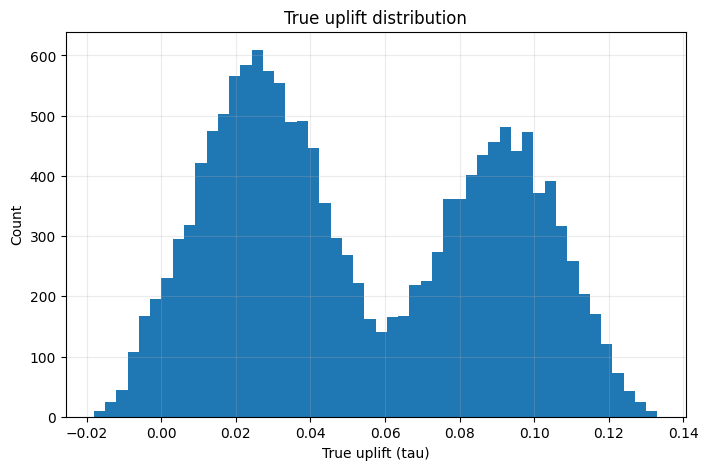

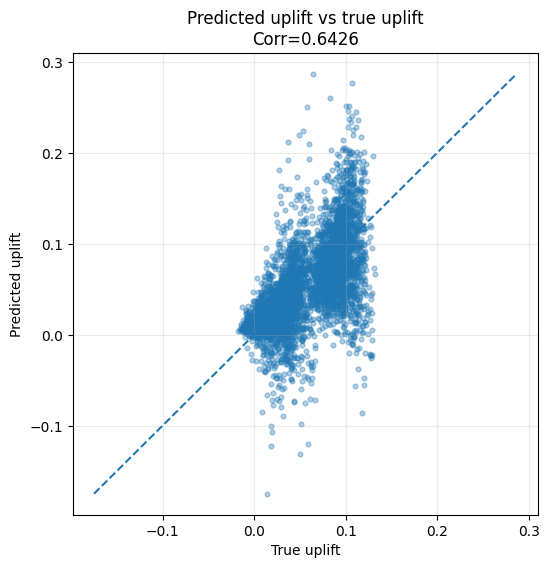

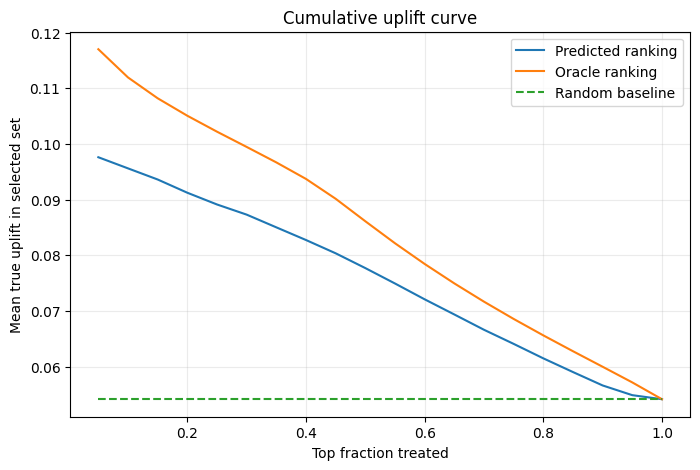

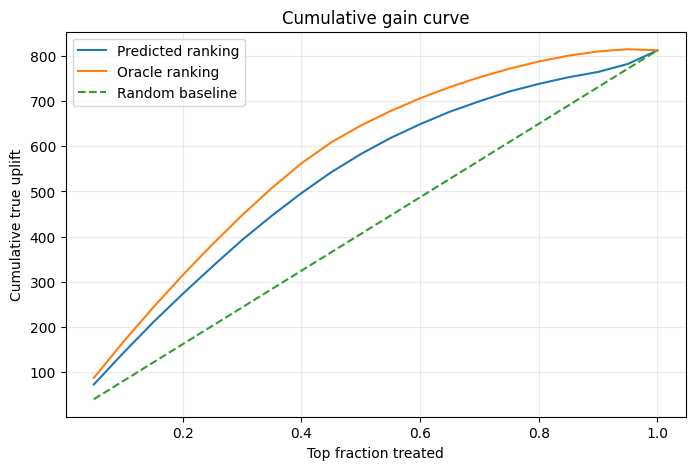

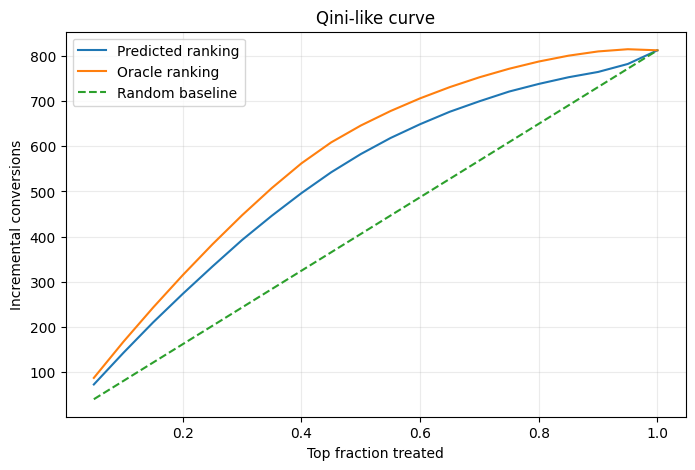

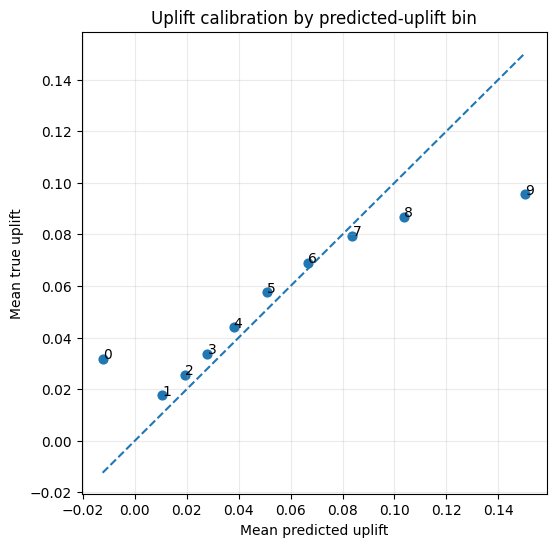

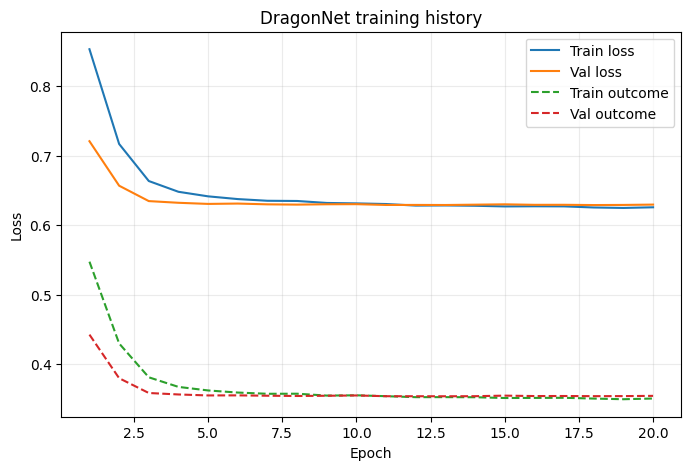

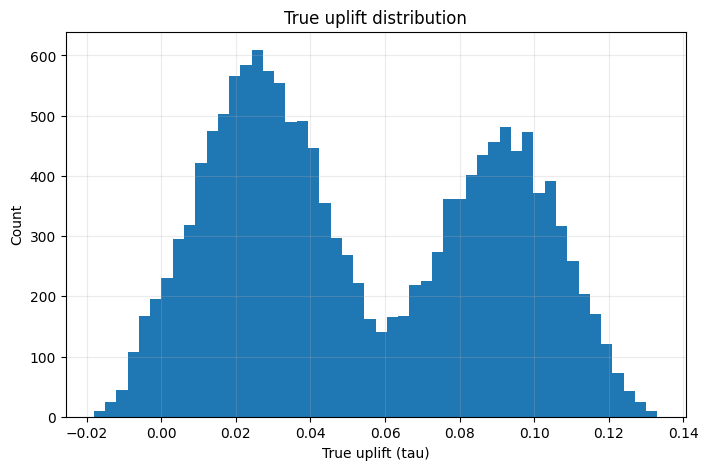

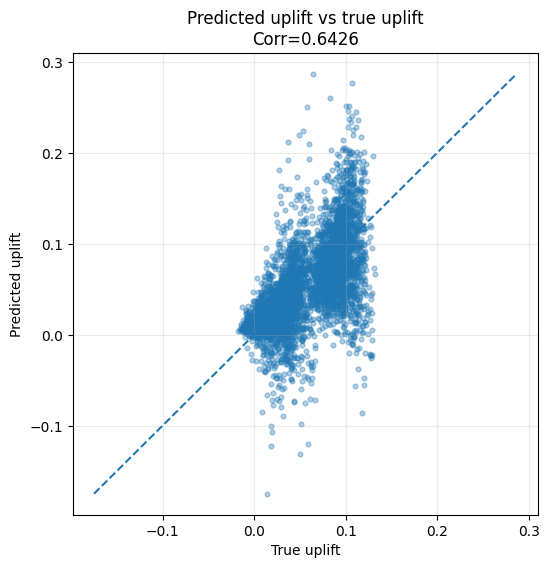

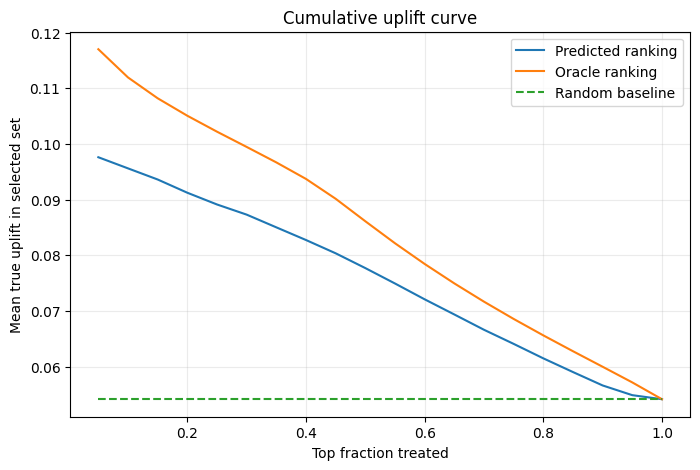

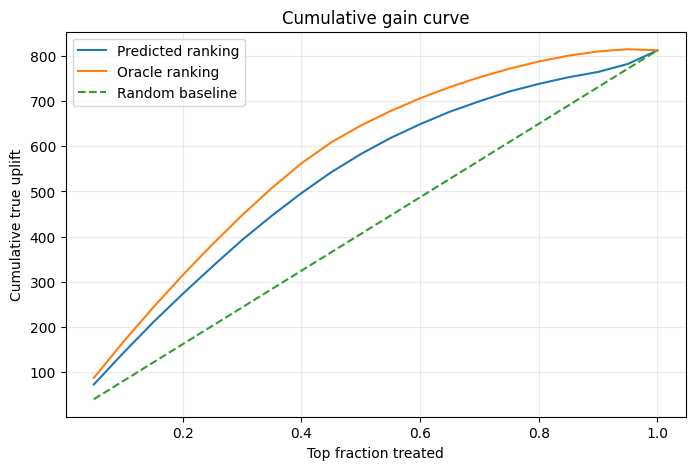

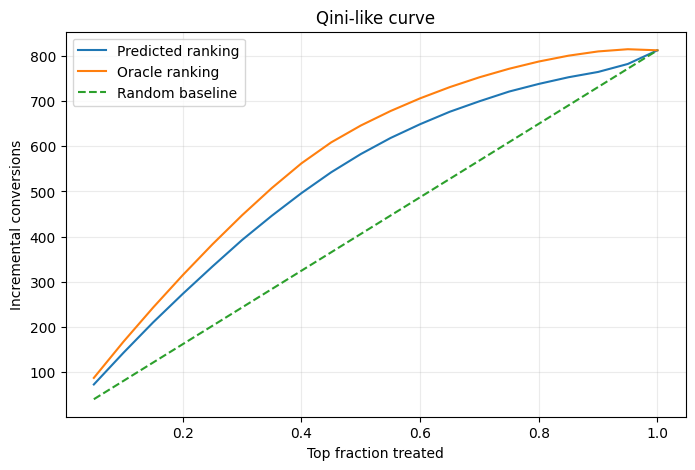

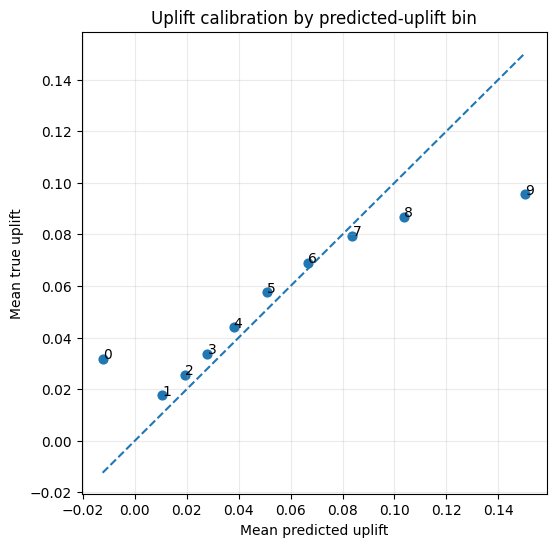

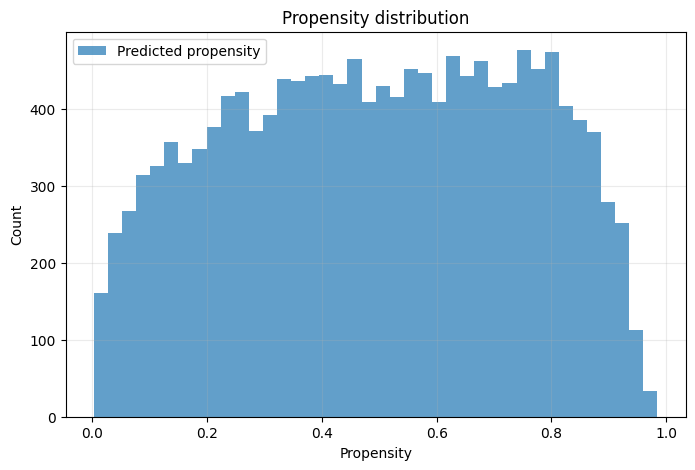

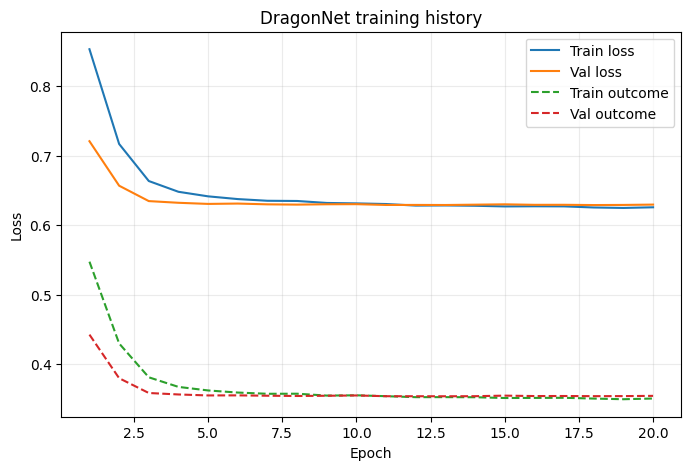

In [5]:
from src.plots import (
    plot_tau_histogram,
    plot_pred_vs_true_uplift,
    plot_uplift_curve,
    plot_cumulative_gain_curve,
    plot_qini_curve,
    plot_uplift_calibration,
    plot_propensity_histogram,
    plot_training_history,
    plot_all_uplift_diagnostics,
)

# after you already computed:
# summary
# uplift_curve_df
# qini_df
# calib_df
# pred
# history
# tau_test
# tau_hat
# and optionally df["propensity_true"] split into propensity_test

# individual plots
plot_tau_histogram(tau_test)
plot_pred_vs_true_uplift(tau_true=tau_test, tau_hat=tau_hat)
plot_uplift_curve(uplift_curve_df)
plot_cumulative_gain_curve(uplift_curve_df)
plot_qini_curve(qini_df)
plot_uplift_calibration(calib_df)
plot_training_history(history)

# if you also have true propensity on test:
# plot_propensity_histogram(
#     propensity_hat=pred["propensity_hat"],
#     propensity_true=propensity_test,
# )

# or generate/save everything at once
plot_all_uplift_diagnostics(
    tau_true=tau_test,
    tau_hat=tau_hat,
    uplift_curve_df=uplift_curve_df,
    qini_df=qini_df,
    calib_df=calib_df,
    history=history,
    propensity_hat=pred["propensity_hat"],
    # propensity_true=propensity_test,
    output_dir="images",
    show=True,
)